# PD Voice Embedding Analysis Report (Wav2Vec2 / HuBERT)

This notebook is presentation-ready for a professor meeting.
It follows the segmentation-first pipeline: **early (0-3s), middle (3-7s), late (7-10s)**.

## 1. Environment Setup and Path Configuration (Wav2Vec2/HuBERT Switch)

Set `MODEL_NAME` to either `"Wav2Vec2"` or `"HuBERT"`.
All analysis then reads `metadata.csv` and `embeddings/` for that model.

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

MODEL_NAME = "HuBERT"  # Change to "Wav2Vec2" to switch model input

PROJECT_ROOT = Path.cwd().resolve()
MODEL_ROOT = PROJECT_ROOT / MODEL_NAME
META_PATH = MODEL_ROOT / "metadata.csv"
EMB_ROOT = MODEL_ROOT / "embeddings"
RESULTS_DIR = PROJECT_ROOT / "results" / "embedding_analysis" / MODEL_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("MODEL_NAME:", MODEL_NAME)
print("META_PATH:", META_PATH)
print("EMB_ROOT:", EMB_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)

MODEL_NAME: HuBERT
META_PATH: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/HuBERT/metadata.csv
EMB_ROOT: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/HuBERT/embeddings
RESULTS_DIR: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/results/embedding_analysis/HuBERT


## 2. Load Metadata and Build Subject-Level Segment Triplets (early, middle, late)

We build one row per subject with aligned paths for:
- `early.npy`, `middle.npy`, `late.npy` (mean embeddings, shape `[768]`)
- optional `*_seq.npy` (sequence embeddings, shape `[T, 768]`)

In [15]:
meta = pd.read_csv(META_PATH)
meta = meta[meta["segment"].isin(["early", "middle", "late"])].copy()

if "embedding_path" not in meta.columns:
    raise ValueError("metadata.csv does not contain embedding_path.")

def to_abs_path(p: str) -> Path:
    pth = Path(p)
    if pth.is_absolute():
        return pth
    return PROJECT_ROOT / pth

# Keep mean embeddings only for the main analysis table.
mean_meta = meta[~meta["embedding_path"].astype(str).str.endswith("_seq.npy")].copy()

rows = []
for (stem, cls), grp in mean_meta.groupby(["original_stem", "class"]):
    seg_map = {r.segment: r for r in grp.itertuples(index=False)}
    if not all(seg in seg_map for seg in ["early", "middle", "late"]):
        continue

    p_early = to_abs_path(seg_map["early"].embedding_path)
    p_middle = to_abs_path(seg_map["middle"].embedding_path)
    p_late = to_abs_path(seg_map["late"].embedding_path)

    seq_early = Path(str(p_early).replace("_early.npy", "_early_seq.npy"))
    seq_middle = Path(str(p_middle).replace("_middle.npy", "_middle_seq.npy"))
    seq_late = Path(str(p_late).replace("_late.npy", "_late_seq.npy"))

    rows.append({
        "original_stem": stem,
        "class": cls,
        "label": 1 if cls == "PD" else 0,
        "early_path": p_early,
        "middle_path": p_middle,
        "late_path": p_late,
        "early_seq_path": seq_early,
        "middle_seq_path": seq_middle,
        "late_seq_path": seq_late,
        "has_seq": seq_early.exists() and seq_middle.exists() and seq_late.exists(),
    })

triplets = pd.DataFrame(rows)
print("Triplet subjects:", len(triplets))
print("Class distribution:")
print(triplets["class"].value_counts())
triplets.head(3)

Triplet subjects: 1247
Class distribution:
class
HC    909
PD    338
Name: count, dtype: int64


,original_stem,class,label,early_path,middle_path,late_path,early_seq_path,middle_seq_path,late_seq_path,has_seq
0,000c901b-049b-41e1-b238-eae9c209edaa_6023402,PD,1,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,True
1,003d12eb-7a9c-4ab2-aed8-e6097c5d5c38_6013609,HC,0,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,True
2,0055c363-8a10-4081-91e2-dae9d082752c_6011857,HC,0,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,/home/bs00956/Desktop/Personal/PD/Pipeline-Imp...,True


## 3. Meeting-Ready Intuitive Explanations (Embedding, 768-D, PD Relevance, Segmentation)

**What is an audio embedding?**
- In Wav2Vec2/HuBERT, an embedding is a compressed numeric summary of voice characteristics.
- Instead of raw waveform values, we use a learned feature vector that captures speech style, articulation, stability, and acoustic texture.

**What does a 768-dimensional vector mean?**
- Each segment is represented by 768 learned features.
- These features are not manually named (like pitch or jitter), but jointly encode many acoustic traits.
- The model learns this representation from large speech corpora, then we reuse it for PD analysis.

**Why useful for PD detection?**
- PD often changes voice smoothness, control, and consistency.
- Embeddings can capture subtle patterns that are hard to see from waveform directly.
- A classifier can use these vectors to separate PD and HC cohorts.

**Why early/middle/late segmentation matters?**
- PD effects can evolve within a 10-second utterance.
- Early reflects baseline phonation, middle reflects sustained phonation, late often reflects fatigue/degradation.
- Segment-wise embeddings preserve this temporal progression instead of averaging everything into one signal.

## 4. Single-Subject Deep Dive: Load `early.npy`, `middle.npy`, `late.npy`, Optional `*_seq.npy`

In [16]:
# Pick one subject with complete triplets.
one = triplets.iloc[0]

f_early = np.load(one["early_path"])
f_middle = np.load(one["middle_path"])
f_late = np.load(one["late_path"])

seq_early = np.load(one["early_seq_path"]) if one["early_seq_path"].exists() else None
seq_middle = np.load(one["middle_seq_path"]) if one["middle_seq_path"].exists() else None
seq_late = np.load(one["late_seq_path"]) if one["late_seq_path"].exists() else None

print("Subject:", one["original_stem"], "| Class:", one["class"])
print("Mean embedding shapes:", f_early.shape, f_middle.shape, f_late.shape)
print("Has sequence embeddings:", bool(one["has_seq"]))

for name, vec in [("early", f_early), ("middle", f_middle), ("late", f_late)]:
    print(f"{name:>6} | mean={vec.mean():.4f} std={vec.std():.4f} norm={np.linalg.norm(vec):.4f}")

Subject: 000c901b-049b-41e1-b238-eae9c209edaa_6023402 | Class: PD
Mean embedding shapes: (768,) (768,) (768,)
Has sequence embeddings: True
 early | mean=0.0089 std=0.3145 norm=8.7196
middle | mean=0.0098 std=0.3959 norm=10.9753
  late | mean=0.0099 std=0.3910 norm=10.8390


## 5. Single-Subject Visuals: 768-Feature Line Plot, ΔF=(Flate−Fearly), Cosine Similarity

Cosine similarities
early-middle: 0.8235
middle-late : 0.9664
early-late  : 0.8509


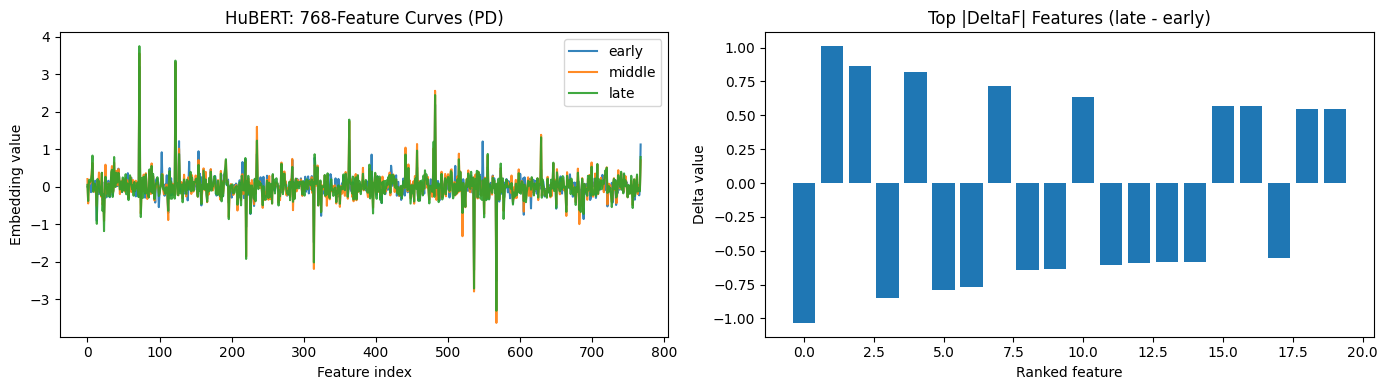

In [17]:
def cos(a, b):
    return float(cosine_similarity(a.reshape(1, -1), b.reshape(1, -1))[0, 0])

delta_f = f_late - f_early

cos_em = cos(f_early, f_middle)
cos_ml = cos(f_middle, f_late)
cos_el = cos(f_early, f_late)

print("Cosine similarities")
print(f"early-middle: {cos_em:.4f}")
print(f"middle-late : {cos_ml:.4f}")
print(f"early-late  : {cos_el:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 768-d line plot for verbal explanation.
axes[0].plot(f_early, label="early", alpha=0.9)
axes[0].plot(f_middle, label="middle", alpha=0.9)
axes[0].plot(f_late, label="late", alpha=0.9)
axes[0].set_title(f"{MODEL_NAME}: 768-Feature Curves ({one['class']})")
axes[0].set_xlabel("Feature index")
axes[0].set_ylabel("Embedding value")
axes[0].legend()

# Top changing features in |late - early|.
k = 20
top_idx = np.argsort(np.abs(delta_f))[-k:][::-1]
axes[1].bar(np.arange(k), delta_f[top_idx])
axes[1].set_title("Top |DeltaF| Features (late - early)")
axes[1].set_xlabel("Ranked feature")
axes[1].set_ylabel("Delta value")

plt.tight_layout()
fig.savefig(RESULTS_DIR / "single_subject_line_and_delta.png", dpi=160)
plt.show()

## 6. Single-Subject Heatmap for Sequence Embedding [T,768]

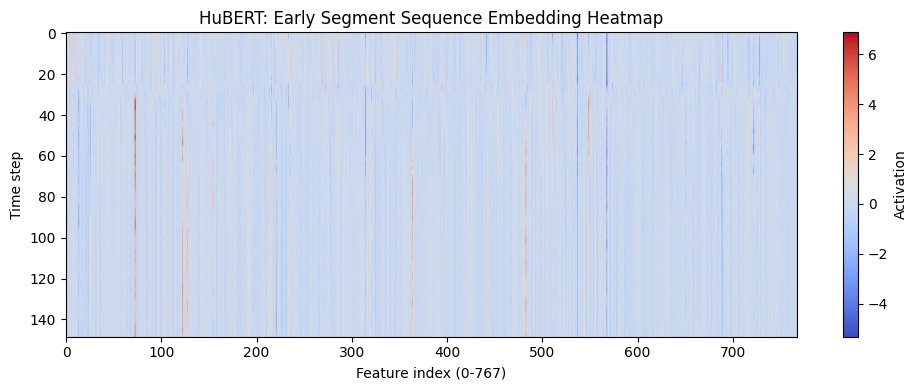

In [18]:
if seq_early is None:
    print("Sequence embeddings not found for this subject.")
else:
    plt.figure(figsize=(10, 4))
    plt.imshow(seq_early, aspect="auto", cmap="coolwarm")
    plt.colorbar(label="Activation")
    plt.title(f"{MODEL_NAME}: Early Segment Sequence Embedding Heatmap")
    plt.xlabel("Feature index (0-767)")
    plt.ylabel("Time step")
    plt.tight_layout()
    plt.show()

## 7. Multi-Subject Analysis: PD vs HC Similarity Distributions and Statistical Summaries

         cos_em                        cos_ml                        cos_el  \
           mean    median       std      mean    median       std      mean   
class                                                                         
HC     0.854873  0.864003  0.080405  0.917214  0.939654  0.079266  0.833558   
PD     0.850792  0.854969  0.090670  0.912879  0.940689  0.087675  0.826430   

                          delta_norm                      
         median       std       mean    median       std  
class                                                     
HC     0.850908  0.094724   5.257486  5.253367  1.466902  
PD     0.847509  0.097135   5.496657  5.475965  1.557463  


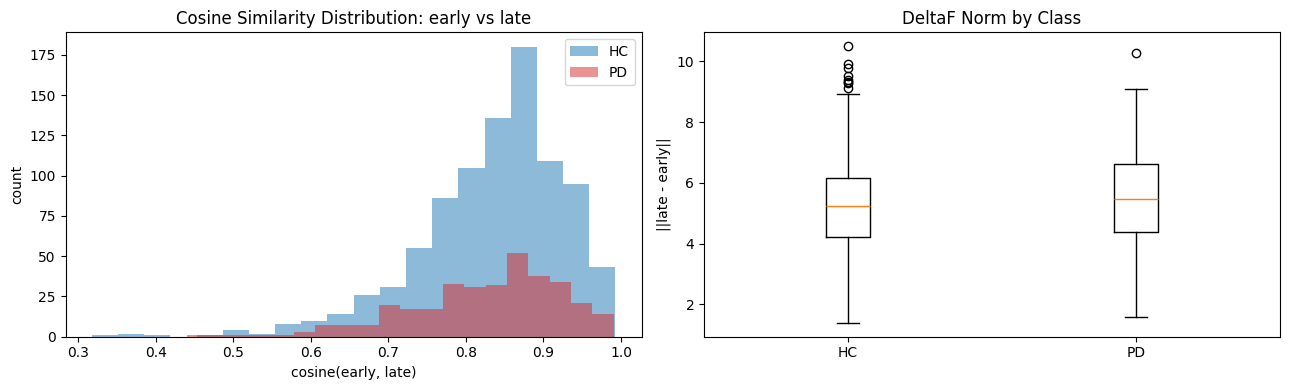

In [19]:
records = []
for r in triplets.itertuples(index=False):
    fe = np.load(r.early_path)
    fm = np.load(r.middle_path)
    fl = np.load(r.late_path)
    cls = r[1]

    records.append({
        "subject": r.original_stem,
        "class": cls,
        "label": r.label,
        "cos_em": cos(fe, fm),
        "cos_ml": cos(fm, fl),
        "cos_el": cos(fe, fl),
        "delta_norm": float(np.linalg.norm(fl - fe)),
    })

multi_df = pd.DataFrame(records)

summary_stats = multi_df.groupby("class")[["cos_em", "cos_ml", "cos_el", "delta_norm"]].agg(["mean", "median", "std"])
print(summary_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for cls, color in [("HC", "tab:blue"), ("PD", "tab:red")]:
    x = multi_df.loc[multi_df["class"] == cls, "cos_el"].values
    axes[0].hist(x, bins=20, alpha=0.5, label=cls, color=color)
axes[0].set_title("Cosine Similarity Distribution: early vs late")
axes[0].set_xlabel("cosine(early, late)")
axes[0].set_ylabel("count")
axes[0].legend()

box_data = [multi_df.loc[multi_df["class"] == "HC", "delta_norm"], multi_df.loc[multi_df["class"] == "PD", "delta_norm"]]
axes[1].boxplot(box_data, tick_labels=["HC", "PD"])
axes[1].set_title("DeltaF Norm by Class")
axes[1].set_ylabel("||late - early||")

plt.tight_layout()
fig.savefig(RESULTS_DIR / "multi_subject_similarity_distributions.png", dpi=160)
plt.show()

## 8. Dimensionality Reduction (PCA / t-SNE): Class Clusters and Segment-Wise Clusters

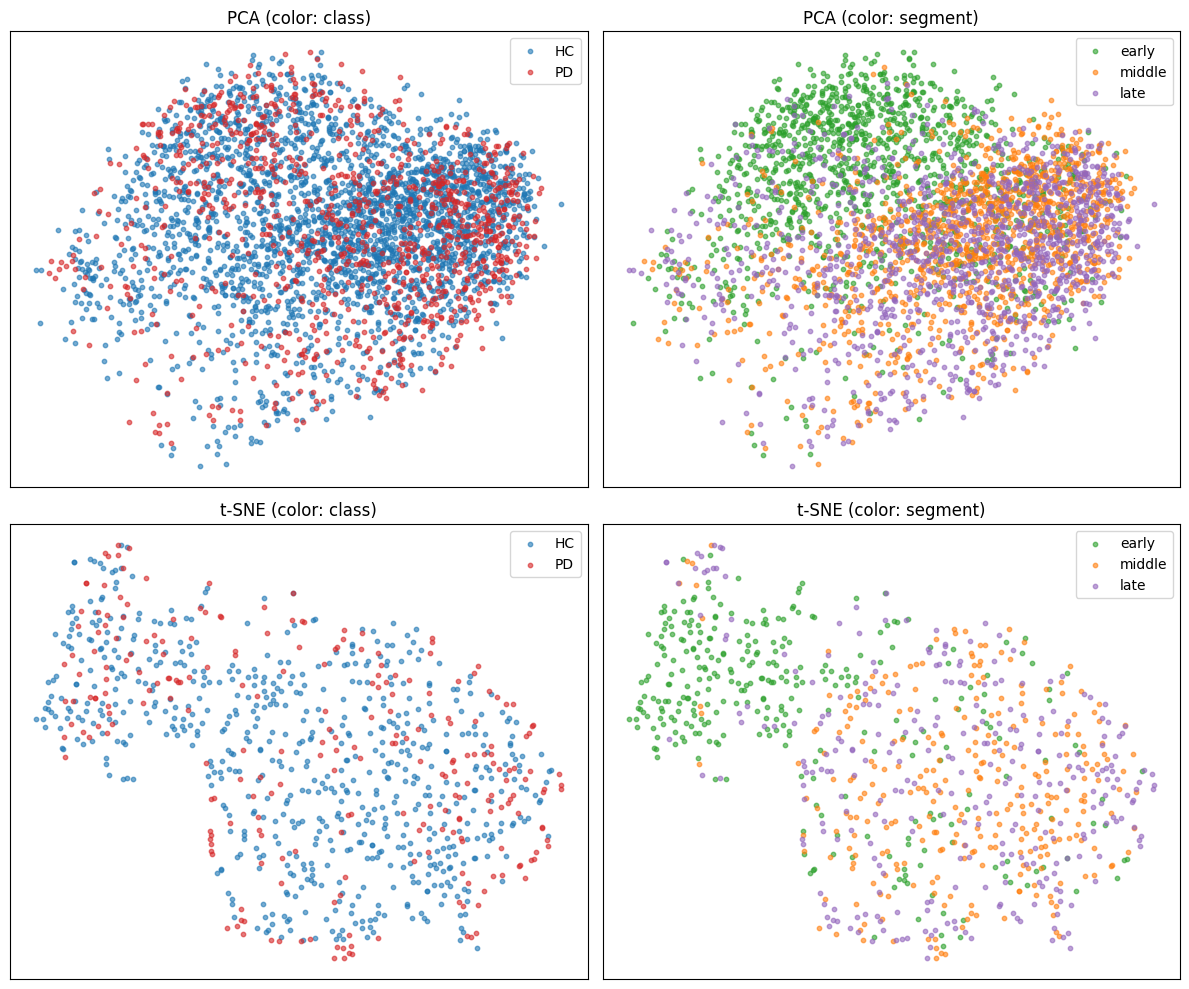

In [20]:
plot_rows = []
for r in triplets.itertuples(index=False):
    cls = r[1]
    for seg, p in [("early", r.early_path), ("middle", r.middle_path), ("late", r.late_path)]:
        plot_rows.append({
            "subject": r.original_stem,
            "class": cls,
            "segment": seg,
            "vec": np.load(p),
        })

plot_df = pd.DataFrame(plot_rows)
X = np.stack(plot_df["vec"].values)

# PCA (fast and stable)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)

# t-SNE on a subset for speed
max_tsne = min(900, len(X))
idx_tsne = np.random.choice(len(X), size=max_tsne, replace=False)
X_tsne_in = X[idx_tsne]
class_tsne = plot_df.iloc[idx_tsne]["class"].values
seg_tsne = plot_df.iloc[idx_tsne]["segment"].values

X_tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca").fit_transform(X_tsne_in)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for cls, color in [("HC", "tab:blue"), ("PD", "tab:red")]:
    m = (plot_df["class"].values == cls)
    axes[0, 0].scatter(X_pca[m, 0], X_pca[m, 1], s=10, alpha=0.6, c=color, label=cls)
axes[0, 0].set_title("PCA (color: class)")
axes[0, 0].legend()

for seg, color in [("early", "tab:green"), ("middle", "tab:orange"), ("late", "tab:purple")]:
    m = (plot_df["segment"].values == seg)
    axes[0, 1].scatter(X_pca[m, 0], X_pca[m, 1], s=10, alpha=0.6, c=color, label=seg)
axes[0, 1].set_title("PCA (color: segment)")
axes[0, 1].legend()

for cls, color in [("HC", "tab:blue"), ("PD", "tab:red")]:
    m = (class_tsne == cls)
    axes[1, 0].scatter(X_tsne[m, 0], X_tsne[m, 1], s=10, alpha=0.6, c=color, label=cls)
axes[1, 0].set_title("t-SNE (color: class)")
axes[1, 0].legend()

for seg, color in [("early", "tab:green"), ("middle", "tab:orange"), ("late", "tab:purple")]:
    m = (seg_tsne == seg)
    axes[1, 1].scatter(X_tsne[m, 0], X_tsne[m, 1], s=10, alpha=0.6, c=color, label=seg)
axes[1, 1].set_title("t-SNE (color: segment)")
axes[1, 1].legend()

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
fig.savefig(RESULTS_DIR / "pca_tsne_clusters.png", dpi=160)
plt.show()

## 9. Temporal Signal Analysis: Segment Informativeness and ΔF Behavior

In [21]:
X_early = np.stack([np.load(p) for p in triplets["early_path"]])
X_middle = np.stack([np.load(p) for p in triplets["middle_path"]])
X_late = np.stack([np.load(p) for p in triplets["late_path"]])
X_delta = X_late - X_early
y = triplets["label"].values

def cv_probe(X, y, seed=42):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    accs, f1s, aucs = [], [], []
    for tr, va in skf.split(X, y):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[tr])
        Xva = scaler.transform(X[va])

        clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed)
        clf.fit(Xtr, y[tr])

        pred = clf.predict(Xva)
        prob = clf.predict_proba(Xva)[:, 1]

        accs.append(accuracy_score(y[va], pred))
        f1s.append(f1_score(y[va], pred))
        aucs.append(roc_auc_score(y[va], prob))
    return {
        "acc": float(np.mean(accs)),
        "f1": float(np.mean(f1s)),
        "auc": float(np.mean(aucs)),
    }

probe_results = {
    "early": cv_probe(X_early, y),
    "middle": cv_probe(X_middle, y),
    "late": cv_probe(X_late, y),
    "delta(late-early)": cv_probe(X_delta, y),
}

probe_df = pd.DataFrame(probe_results).T
probe_df

,acc,f1,auc
early,0.728954,0.533345,0.759666
middle,0.728138,0.532082,0.729682
late,0.682448,0.435925,0.665232
delta(late-early),0.634323,0.398341,0.616429


## 10. Auto-Generated Interpretation Blocks for Research Discussion

In [22]:
best_seg = probe_df["auc"].idxmax()
late_var_pd = float(multi_df.loc[multi_df["class"] == "PD", "delta_norm"].mean())
late_var_hc = float(multi_df.loc[multi_df["class"] == "HC", "delta_norm"].mean())

print("Interpretation block")
print("- PD vs HC separation quality (AUC):")
print(probe_df["auc"].sort_values(ascending=False))
print(f"- Most informative view by AUC: {best_seg}")
print(f"- Mean DeltaF norm (PD): {late_var_pd:.4f}")
print(f"- Mean DeltaF norm (HC): {late_var_hc:.4f}")

if late_var_pd > late_var_hc:
    print("- Late-stage change appears stronger in PD than HC (DeltaF supports progression signal).")
else:
    print("- Late-stage change is not stronger in PD for this sample; needs deeper validation.")

Interpretation block
- PD vs HC separation quality (AUC):
early                0.759666
middle               0.729682
late                 0.665232
delta(late-early)    0.616429
Name: auc, dtype: float64
- Most informative view by AUC: early
- Mean DeltaF norm (PD): 5.4967
- Mean DeltaF norm (HC): 5.2575
- Late-stage change appears stronger in PD than HC (DeltaF supports progression signal).


## 11. Presentation-Ready Short Report Export (Problem, Method, Insights, Limits, Next Steps)

In [23]:
report_text = f"""
1. Problem
Detect Parkinson's Disease (PD) vs Healthy Control (HC) from voice using segmentation-first embeddings.

2. Method
Audio was segmented into early (0-3s), middle (3-7s), and late (7-10s). We analyzed precomputed {MODEL_NAME} embeddings (mean [768], optional sequence [T,768]).

3. Embedding Insight
Segment embeddings show subject-level differences across 768 learned acoustic features.
Best AUC view in this run: {best_seg}.

4. Temporal Insight (early -> late)
DeltaF = late - early captures temporal progression/fatigue-like changes.
Mean DeltaF norm (PD): {late_var_pd:.4f}
Mean DeltaF norm (HC): {late_var_hc:.4f}

5. Key Observations
- Cosine distributions (early vs late) differ by cohort.
- Segment-specific probes show informativeness varies by segment.
- DeltaF provides a direct temporal change signal.

6. Limitations
- Subject-level class imbalance can bias some metrics.
- PCA/t-SNE are visualization tools, not definitive evidence.
- Results depend on current metadata filtering and available triplets.

7. Next Steps
- Add confidence intervals and statistical testing.
- Extend with gated fusion + contrastive/classification joint training.
- Compare Wav2Vec2 and HuBERT side-by-side under identical splits.
""".strip()

print(report_text)

report_path = RESULTS_DIR / "embedding_analysis_report.txt"
report_path.write_text(report_text, encoding="utf-8")
print("\nSaved report:", report_path)

1. Problem
Detect Parkinson's Disease (PD) vs Healthy Control (HC) from voice using segmentation-first embeddings.

2. Method
Audio was segmented into early (0-3s), middle (3-7s), and late (7-10s). We analyzed precomputed HuBERT embeddings (mean [768], optional sequence [T,768]).

3. Embedding Insight
Segment embeddings show subject-level differences across 768 learned acoustic features.
Best AUC view in this run: early.

4. Temporal Insight (early -> late)
DeltaF = late - early captures temporal progression/fatigue-like changes.
Mean DeltaF norm (PD): 5.4967
Mean DeltaF norm (HC): 5.2575

5. Key Observations
- Cosine distributions (early vs late) differ by cohort.
- Segment-specific probes show informativeness varies by segment.
- DeltaF provides a direct temporal change signal.

6. Limitations
- Subject-level class imbalance can bias some metrics.
- PCA/t-SNE are visualization tools, not definitive evidence.
- Results depend on current metadata filtering and available triplets.

7. N

In [24]:
# Save key figures for meeting slides.
fig1_path = RESULTS_DIR / "single_subject_line_and_delta.png"
fig2_path = RESULTS_DIR / "multi_subject_similarity_distributions.png"
fig3_path = RESULTS_DIR / "pca_tsne_clusters.png"

print("Figure paths for meeting:")
print("-", fig1_path)
print("-", fig2_path)
print("-", fig3_path)
print("Run this cell after plotting cells if you want explicit savefig calls there.")

Figure paths for meeting:
- /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/results/embedding_analysis/HuBERT/single_subject_line_and_delta.png
- /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/results/embedding_analysis/HuBERT/multi_subject_similarity_distributions.png
- /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/results/embedding_analysis/HuBERT/pca_tsne_clusters.png
Run this cell after plotting cells if you want explicit savefig calls there.
